In [1]:
import requests
import bs4
import re 


def get_page(url: str) -> str:
    """
    Завантажує HTML-код сторінки за URL.
    
    Args:
        url (str): адреса сторінки
    
    Returns:
        str: HTML-код сторінки
    """
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.0.0 Safari/537.36'
    }
    response = requests.get(url, headers=headers)
    response.encoding = 'utf-8'
    return response.text

def clean(row: str) -> str:
        """
        Очищає текст новини від службових слів, розривів рядків, ком та зайвих пробілів.
        
        Args:
            row (str): текст новини
        
        Returns:
            str: очищений текст
        """
        cleaned = row.replace("Дата публікації", "")
        cleaned = cleaned.replace("Категорія", "")
        cleaned = cleaned.replace('\n', ' ')
        cleaned = re.sub(r' +', ' ', cleaned).strip()
        cleaned = cleaned.replace(',', '')
        return cleaned


def parse_tsn(page: str):
    
    """
    Парсить HTML сторінки і знаходить елементи новин.
    
    Args:
        page (str): HTML-код сторінки
    
    Returns:
        list: список тегів <li> з класом 'l-entries__item'
    """
    soup = bs4.BeautifulSoup(page, 'lxml')
    quotes = soup.find_all('li', class_='l-entries__item')
    return [clean(q.text) for q in quotes]

def parse_korrespondent(page: str):
    """Парсить заголовки новин з ukr.net."""
    soup = bs4.BeautifulSoup(page, 'lxml')
    items = soup.find_all('div', class_='article__title')
    headlines = []
    for item in items:
        a = item.find('a')
        if a:
            headlines.append(a.text.strip())
    return [clean(h) for h in headlines]

def parse_up(page: str):
    soup = bs4.BeautifulSoup(page, 'lxml')
    items = soup.find_all('div', class_='article_title')
    headlines = []
    for item in items:
        a = item.find('a')
        if a:
            headlines.append(a.text.strip())
    return [clean(h) for h in headlines]


In [2]:
def proccess_pages(pages: int, url: str) -> str:
    """
    Завантажує HTML код декількох сторінок і об'єднує їх в один рядок.
    
    Args:
        pages (int): кількість сторінок для завантаження
        url (str): базовий URL
    
    Returns:
        str: об'єднаний HTML код всіх сторінок
    """
    page = get_page(url)
    for i in range(2, pages+1):
        page += get_page(url + f"/page-{i}")
    return page


In [3]:
tsn = parse_tsn(proccess_pages(10, "https://tsn.ua/news"))

In [4]:
ukr_pravda = parse_up(get_page("https://www.pravda.com.ua/news/"))

In [5]:
korrespondent = parse_korrespondent(get_page("https://ua.korrespondent.net/"))

In [6]:
def append(rows, path: str):
    """
    Зберігає список рядків у файл.
    
    Args:
        rows (list): список рядків для збереження
        path (str): шлях до файлу
    """
    try:
        with open(path, 'a', encoding='utf-8') as f:
            for line in rows:
                f.write(line + '\n')
    except Exception as e:
        print("Could not save the results:", e)

In [7]:
def filter_tsn(lines):
    """
    Зчитує текст з файлу та видаляє службові слова
    (наприклад, 'ТСН', 'Тема') на початку рядків.
    Повертає список очищених рядків.
    """

    for i, l in enumerate(lines):
        split = l.split()
        for _ in range(6):
            if split and (split[0] == 'ТСН' or split[0] == "Тема"):
                split.pop(0)
            if split:
                split.pop(0)
            
        lines[i] = " ".join(split)
    return [l for l in lines if l]
tsn = filter_tsn(tsn)

In [8]:
path = "result.txt"
with open(path, 'w'):
    pass
append(ukr_pravda, path)
append(korrespondent, path)
append(tsn, path)

In [9]:
def save(rows, path: str):
    """
    Зберігає список рядків у файл.
    
    Args:
        rows (list): список рядків для збереження
        path (str): шлях до файлу
    """
    try:
        with open(path, 'w', encoding='utf-8') as f:
            for line in rows:
                f.write(line + '\n')
    except Exception as e:
        print("Could not save the results:", e)

In [10]:
save(ukr_pravda, "ukr_pravda.txt")
save(tsn, "tsn.txt")
save(korrespondent, "korrespondent.txt")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


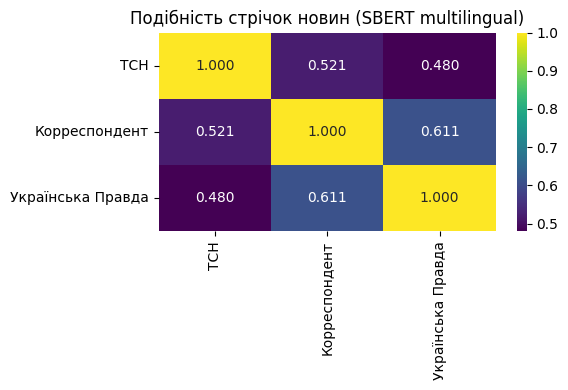

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== ТСН ===
Позитивних:  9
Негативних:  34
Нейтральних: 57
Середній score: -0.166

=== Корреспондент ===
Позитивних:  10
Негативних:  30
Нейтральних: 83
Середній score: -0.120

=== Українська правда ===
Позитивних:  3
Негативних:  19
Нейтральних: 48
Середній score: -0.154


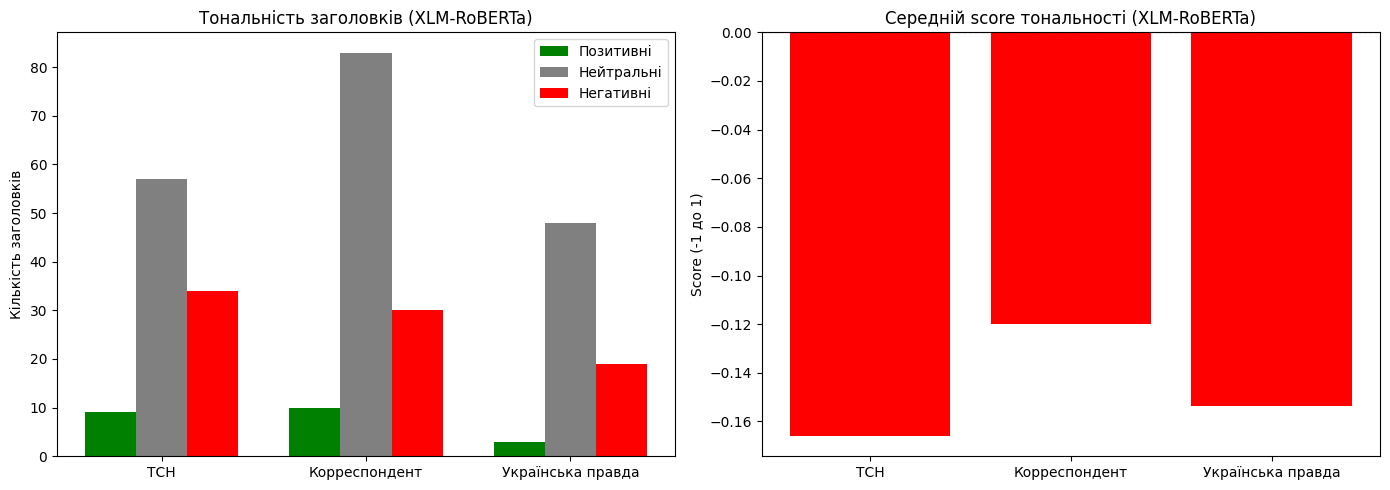

In [12]:
# ============================================================
# ПОРІВНЯЛЬНИЙ АНАЛІЗ ВМІСТУ — HuggingFace (нейронна мережа)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
import numpy as np


sbert_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

news_labels = ["ТСН", "Корреспондент", "Українська Правда"]
news_texts  = [" ".join(tsn), " ".join(korrespondent), " ".join(ukr_pravda)]

embeddings = sbert_model.encode(news_texts, convert_to_tensor=True)

similarity_matrix = util.cos_sim(embeddings, embeddings).cpu().numpy()

plt.figure(figsize=(6, 4))
sns.heatmap(
    similarity_matrix,
    annot=True,
    xticklabels=news_labels,
    yticklabels=news_labels,
    cmap="viridis",
    fmt=".3f"
)
plt.title("Подібність стрічок новин (SBERT multilingual)")
plt.tight_layout()
plt.show()


# ============================================================
# АНАЛІЗ ТОНАЛЬНОСТІ — HuggingFace (нейронна мережа)
# ============================================================
from transformers import pipeline

# Мультилінгвальна модель тональності на базі RoBERTa
sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

def analyze_sentiment_nn(headlines, source_name):
    results = {"positive": 0, "negative": 0, "neutral": 0}
    scores  = []

    for headline in headlines:
        try:
            result = sentiment_model(headline[:512])[0]  # обрізаємо до 512 токенів
            label  = result['label'].lower()
            score  = result['score']

            if label == "positive":
                results["positive"] += 1
                scores.append(score)
            elif label == "negative":
                results["negative"] += 1
                scores.append(-score)
            else:
                results["neutral"] += 1
                scores.append(0)
        except Exception as e:
            print(f"Помилка: {e}")
            continue

    avg = sum(scores) / len(scores) if scores else 0

    print(f"\n=== {source_name} ===")
    print(f"Позитивних:  {results['positive']}")
    print(f"Негативних:  {results['negative']}")
    print(f"Нейтральних: {results['neutral']}")
    print(f"Середній score: {avg:.3f}")

    return results, avg

# Аналіз для кожного джерела
tsn_nn_sentiment, tsn_nn_avg = analyze_sentiment_nn(tsn,           "ТСН")
kor_nn_sentiment, kor_nn_avg = analyze_sentiment_nn(korrespondent, "Корреспондент")
up_nn_sentiment,  up_nn_avg  = analyze_sentiment_nn(ukr_pravda,    "Українська правда")


# ============================================================
# ВІЗУАЛІЗАЦІЯ ТОНАЛЬНОСТІ
# ============================================================
sources     = ["ТСН", "Корреспондент", "Українська правда"]
sentiments  = [tsn_nn_sentiment, kor_nn_sentiment, up_nn_sentiment]
avgs        = [tsn_nn_avg,       kor_nn_avg,       up_nn_avg]

positive = [s["positive"] for s in sentiments]
negative = [s["negative"] for s in sentiments]
neutral  = [s["neutral"]  for s in sentiments]

x     = np.arange(len(sources))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(x - width, positive, width, label="Позитивні", color="green")
axes[0].bar(x,         neutral,  width, label="Нейтральні", color="gray")
axes[0].bar(x + width, negative, width, label="Негативні",  color="red")
axes[0].set_xticks(x)
axes[0].set_xticklabels(sources)
axes[0].set_title("Тональність заголовків (XLM-RoBERTa)")
axes[0].set_ylabel("Кількість заголовків")
axes[0].legend()


colors = ["green" if a > 0 else "red" if a < 0 else "gray" for a in avgs]
axes[1].bar(sources, avgs, color=colors)
axes[1].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Середній score тональності (XLM-RoBERTa)")
axes[1].set_ylabel("Score (-1 до 1)")

plt.tight_layout()
plt.show()